In [105]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from spacy.symbols import mark

In [86]:
# prepare all the dataframe
fut_price = pd.read_excel('../data/processed/E-mini_price.xlsx')
fed_fund_rate = pd.read_excel('../data/processed/SOFR.xlsx')
dividend = pd.read_excel('../data/processed/spx_dividend.xlsx')
spx_price = pd.read_excel('../data/processed/spx_close.xlsx')

In [87]:
dfs = {
    'fut_price': fut_price,
    'fed_fund_rate': fed_fund_rate,
    'dividend': dividend,
    'spx_close': spx_price
}

for name, df in dfs.items():
    df['Date'] = pd.to_datetime(df['Date'])
    dfs[name] = df.set_index('Date')

fut_price, fed_fund_rate, dividend, spx_price = dfs.values()

In [88]:
analysis_df = pd.concat([fut_price, spx_price, fed_fund_rate, dividend], axis=1, sort=True)
analysis_df = analysis_df.dropna()

In [89]:
analysis_df.isna().sum()

ESM6               0
ESU6               0
ESZ6               0
^SPX               0
1M                 0
3M                 0
6M                 0
12M                0
Dividends Yield    0
dtype: int64

In [90]:
# time to maturity
expiry = {
    'ESM6': pd.Timestamp('2026-06-19'),
    'ESU6' : pd.Timestamp('2026-09-18'),
    'ESZ6' : pd.Timestamp('2026-12-18'),
}
contracts = ['ESM6', 'ESU6', 'ESZ6']

for c in contracts:
    analysis_df[f'T_{c}'] = (expiry[c] - analysis_df.index).days / 365
    analysis_df[f'T_{c}_days'] = (expiry[c] - analysis_df.index).days
analysis_df

,ESM6,ESU6,ESZ6,^SPX,1M,3M,6M,12M,Dividends Yield,T_ESM6,T_ESM6_days,T_ESU6,T_ESU6_days,T_ESZ6,T_ESZ6_days
Date,,,,,,,,,,,,,,,
2026-01-02,6951.25,7000.00,7046.75,6858.470215,0.036824,0.036498,0.035776,0.034265,0.011610,0.460274,168,0.709589,259,0.958904,350
2026-01-05,6995.25,7044.75,7091.50,6902.049805,0.036749,0.036464,0.035761,0.034283,0.011541,0.452055,165,0.701370,256,0.950685,347
2026-01-06,7039.75,7091.25,7138.50,6944.819824,0.036746,0.036464,0.035749,0.034238,0.011469,0.449315,164,0.698630,255,0.947945,346
2026-01-07,7015.25,7064.50,7109.75,6920.930176,0.036724,0.036481,0.035832,0.034343,0.011512,0.446575,163,0.695890,254,0.945205,345
2026-01-08,7014.00,7063.75,7110.00,6921.459961,0.036739,0.036497,0.035851,0.034350,0.011513,0.443836,162,0.693151,253,0.942466,344
2026-01-09,7058.25,7108.00,7157.75,6966.279785,0.036713,0.036518,0.035918,0.034449,0.011436,0.441096,161,0.690411,252,0.939726,343
2026-01-12,7070.00,7121.00,7170.50,6977.270020,0.036779,0.036669,0.036152,0.034761,0.011420,0.432877,158,0.682192,249,0.931507,340
2026-01-13,7055.25,7107.00,7155.75,6963.740234,0.036802,0.036722,0.036291,0.034994,0.011456,0.430137,157,0.679452,248,0.928767,339
2026-01-14,7019.25,7068.25,7116.75,6926.600098,0.036774,0.036711,0.036277,0.034938,0.011524,0.427397,156,0.676712,247,0.926027,338


In [91]:
tenors = np.array([1/12, 3/12, 6/12, 1])

def interpolate_rate(row, T):
    rates = np.array([row['1M'], row['3M'], row['6M'], row['12M']])
    cs = CubicSpline(tenors, rates, bc_type='natural')
    return cs(T).round(5)

In [92]:
# interpolation: risk-free rate
for c in contracts:
    analysis_df[f'r_{c}'] = analysis_df.apply(lambda row: interpolate_rate(row, row[f'T_{c}']), axis=1)

In [97]:
# fair value and basis
for c in contracts:
    analysis_df[f'Fair_{c}'] = analysis_df['^SPX'] * np.exp(
        (analysis_df[f'r_{c}'] - analysis_df['Dividends Yield'])
        * analysis_df[f'T_{c}']
    )
    analysis_df[f'basis_{c}'] = analysis_df[c] - analysis_df[f'Fair_{c}']

In [101]:
analysis_df[['ESM6', 'Fair_ESM6', 'basis_ESM6', '^SPX','r_ESM6','Dividends Yield','T_ESM6',]].head()


,ESM6,Fair_ESM6,basis_ESM6,^SPX,r_ESM6,Dividends Yield,T_ESM6
Date,,,,,,,
2026-01-02,6951.25,6935.577442,15.672558,6858.470215,0.03590,0.011610,0.460274
2026-01-05,6995.25,6978.503523,16.746477,6902.049805,0.03591,0.011541,0.452055
2026-01-06,7039.75,7021.506187,18.243813,6944.819824,0.03591,0.011469,0.449315
2026-01-07,7015.25,6996.998263,18.251737,6920.930176,0.03599,0.011512,0.446575
2026-01-08,7014.00,6997.154717,16.845283,6921.459961,0.03602,0.011513,0.443836


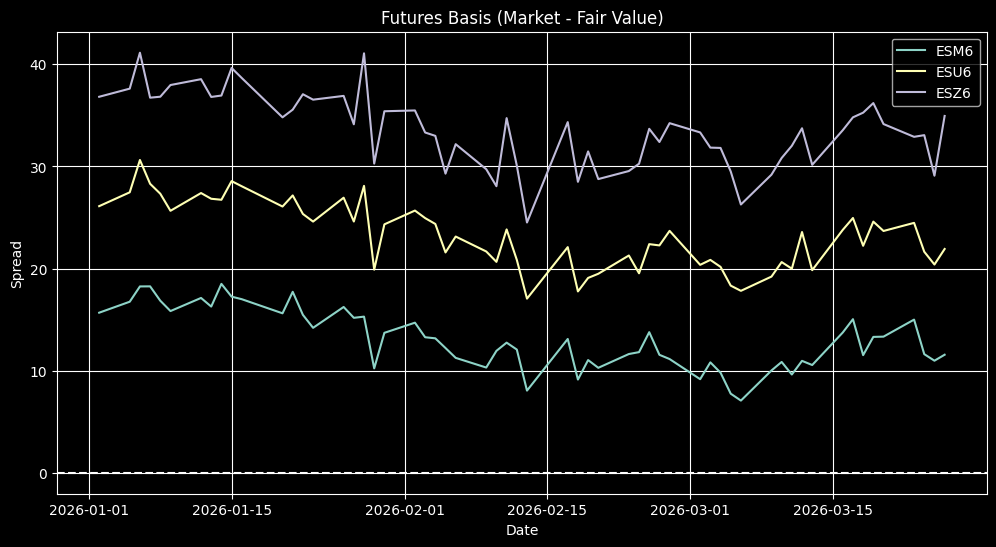

In [112]:
plt.figure(figsize=(12,6))

for c in contracts:
    plt.plot(analysis_df.index, analysis_df[f'basis_{c}'], label=c)

plt.axhline(0, linestyle='--')
plt.title('Futures Basis (Market - Fair Value)')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.legend()
plt.grid(True)
plt.show()

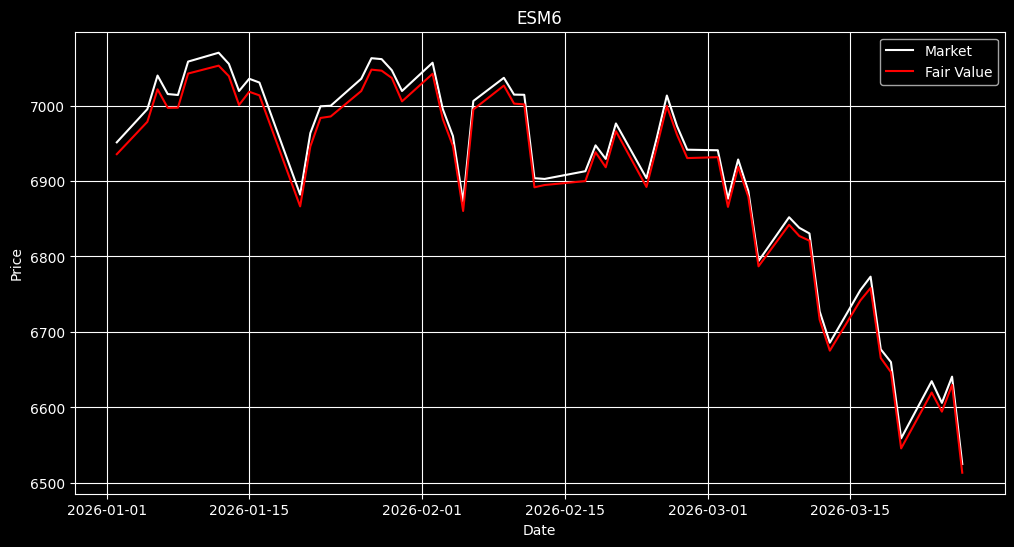

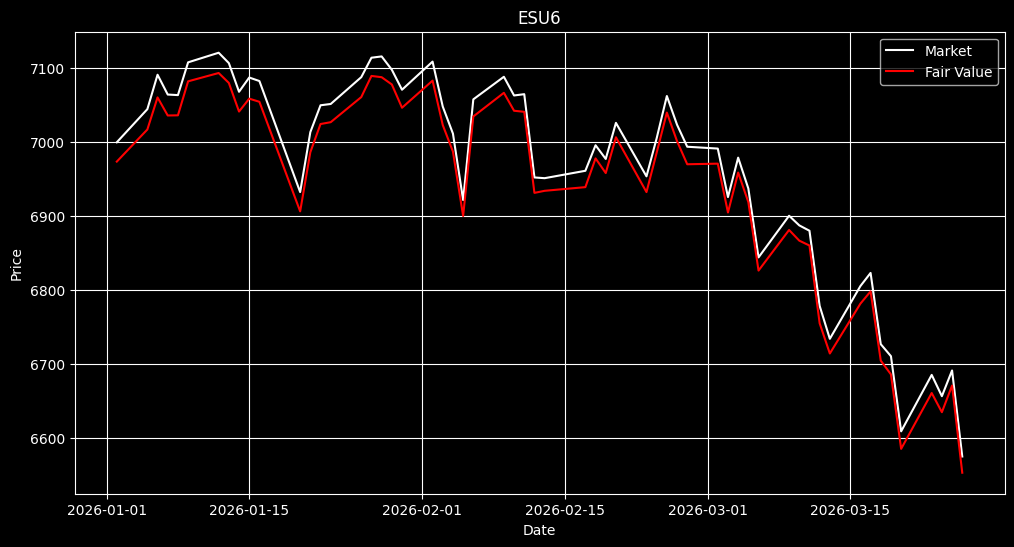

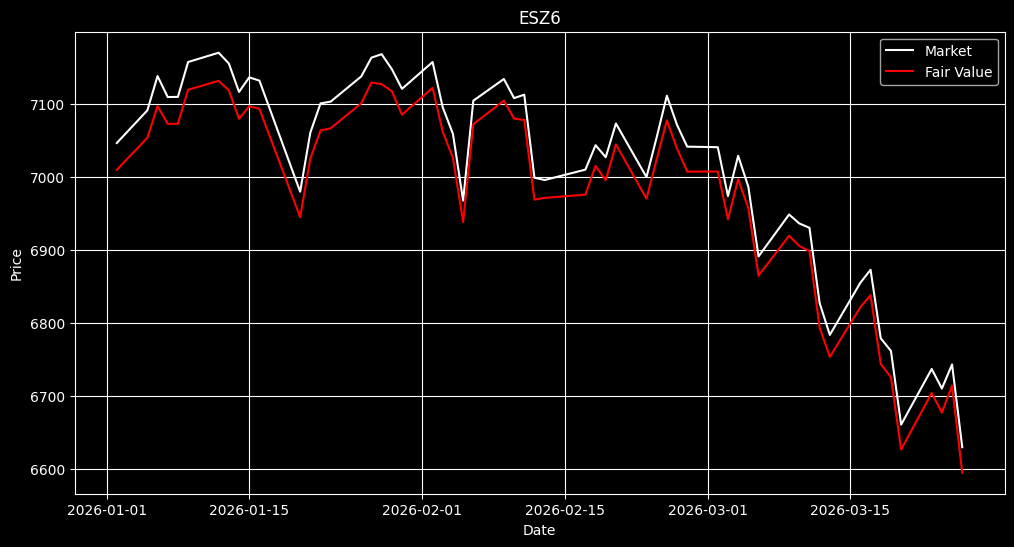

In [128]:
for c in contracts:
    plt.figure(figsize=(12,6))

    plt.plot(analysis_df.index, analysis_df[c], label='Market', color='white')
    plt.plot(analysis_df.index, analysis_df[f'Fair_{c}'], label='Fair Value', color='red')

    plt.title(f'{c}')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

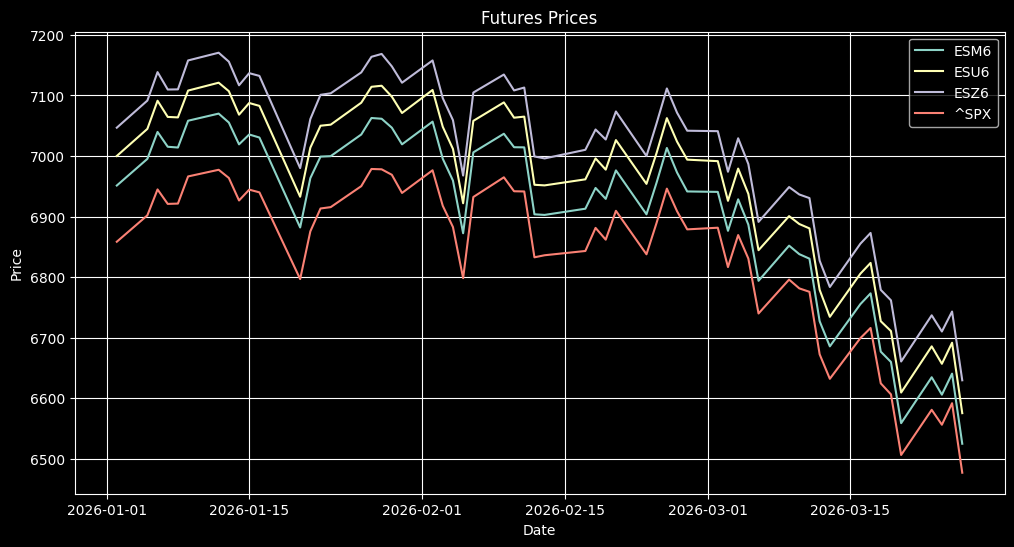

In [141]:
plt.figure(figsize=(12,6))

cols = ['ESM6', 'ESU6', 'ESZ6', '^SPX']

for c in cols:
    plt.plot(analysis_df.index, analysis_df[c], label=c)

plt.title('Futures Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

plt.show()